# UCF-QNRF - EDA

## Dataset context

UCF-QNRF was introduced with *Composition Loss for Counting, Density Map Estimation and Localization in Dense Crowds* (ECCV 2018). The paper describes it as a high-resolution, diverse dense-crowd dataset collected from Flickr, Web Search, and Hajj footage.

Key reported statistics:

- 1,535 JPEG images.
- 1,251,642 dot annotations.
- Standard split: 1,201 train images and 334 test images.
- Counts range from 49 to 12,865 people per image, with median 425 and mean 815.4.

References used for the research notes:

- ECCV page: https://www.ecva.net/papers/eccv_2018/papers_ECCV/html/Haroon_Idrees_Composition_Loss_for_ECCV_2018_paper.php
- PDF: https://openaccess.thecvf.com/content_ECCV_2018/papers/Haroon_Idrees_Composition_Loss_for_ECCV_2018_paper.pdf
- Dataset page: https://www.crcv.ucf.edu/data/ucf-qnrf/


## 1. Mount Google Drive

In [1]:
# try:
#     from google.colab import drive
#     drive.mount("/content/drive")
# except Exception as exc:
#     print("Drive mount skipped. This is expected outside Colab:", exc)

## 2. Configure paths

Edit `DATA_ROOT` only if the dataset is not in `MyDrive/data/UCF-QNRF`.


In [2]:
from pathlib import Path

CANDIDATE_ROOTS = [
    Path("/content/drive/MyDrive/Crowd_flow_est/data/UCF-QNRF"),
    Path("/content/drive/MyDrive/UCF-QNRF"),
    Path("/content/drive/MyDrive/data/UCF-QNRF_ECCV18"),
    Path("/content/drive/MyDrive/UCF-QNRF_ECCV18"),
    Path("./data/UCF-QNRF"),
    Path("./data/UCF-QNRF_ECCV18"),
    Path("../data/UCF-QNRF"),
]

DATA_ROOT = next((p for p in CANDIDATE_ROOTS if p.exists()), CANDIDATE_ROOTS[0])
OUTPUT_DIR = Path("/content/drive/MyDrive/Crowd_flow_est/crowd_counting_eda_outputs/UCF-QNRF") if Path("/content/drive/MyDrive").exists() else Path("./crowd_counting_eda_outputs/UCF-QNRF")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_ROOT: ..\data\UCF-QNRF
OUTPUT_DIR: crowd_counting_eda_outputs\UCF-QNRF


## 3. Imports and helper functions


In [3]:
from pathlib import Path
from functools import lru_cache
import math
import os
import random
import re
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageFile, UnidentifiedImageError
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
print("Ready.")


Ready.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def print_tree(root, max_depth=3, max_entries=80):
    """Print a compact directory tree so paths can be verified quickly."""
    root = Path(root)
    print(f"Root: {root}")
    if not root.exists():
        print("Path does not exist. Edit DATA_ROOT in the path cell above.")
        return
    shown = 0
    for current, dirs, files in os.walk(root):
        current = Path(current)
        depth = len(current.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        if depth == 0:
            print(f"{current.name}/")
        else:
            print(f"{indent}{current.name}/")
        shown += 1
        for fname in sorted(files)[:8]:
            if shown >= max_entries:
                print("  ... tree output truncated")
                return
            print(f"{indent}  {fname}")
            shown += 1
        dirs[:] = sorted(dirs)[:12]
        if shown >= max_entries:
            print("  ... tree output truncated")
            return


def is_image_file(path):
    return Path(path).suffix.lower() in IMAGE_SUFFIXES


def list_images(folder, recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    pattern = "**/*" if recursive else "*"
    return sorted([p for p in folder.glob(pattern) if p.is_file() and is_image_file(p)])


def list_mats(folder, recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    pattern = "**/*.mat" if recursive else "*.mat"
    return sorted([p for p in folder.glob(pattern) if p.is_file()])


def safe_image_info(image_path):
    """Return width, height, mode, and any error string."""
    try:
        with Image.open(image_path) as im:
            width, height = im.size
            mode = im.mode
        return width, height, mode, None
    except Exception as exc:
        return np.nan, np.nan, None, repr(exc)


def _points_candidate(obj):
    """Convert a numeric object to an Nx2 coordinate array when possible."""
    try:
        arr = np.asarray(obj)
    except Exception:
        return None
    if arr.size == 0:
        return np.empty((0, 2), dtype=float)
    if not np.issubdtype(arr.dtype, np.number):
        return None
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        if arr.shape[0] == 2:
            arr = arr.reshape(1, 2)
        else:
            return None
    if arr.ndim != 2:
        return None
    if arr.shape[1] == 2:
        pts = arr
    elif arr.shape[0] == 2:
        pts = arr.T
    else:
        return None
    pts = pts.astype(float)
    pts = pts[np.isfinite(pts).all(axis=1)]
    return pts


def _walk_mat_object(obj, path="root"):
    """Yield all numeric Nx2 arrays reachable inside nested MATLAB structs/cells."""
    pts = _points_candidate(obj)
    if pts is not None:
        yield path, pts
    if hasattr(obj, "_fieldnames"):
        for field in obj._fieldnames:
            try:
                value = getattr(obj, field)
            except Exception:
                continue
            yield from _walk_mat_object(value, f"{path}.{field}")
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for idx, value in enumerate(obj.flat):
            yield from _walk_mat_object(value, f"{path}[{idx}]")
    elif isinstance(obj, (list, tuple)):
        for idx, value in enumerate(obj):
            yield from _walk_mat_object(value, f"{path}[{idx}]")


def extract_points_from_mat(mat_path):
    """Robustly extract point labels from UCF-QNRF or ShanghaiTech .mat files.

    UCF-QNRF usually stores points in `annPoints`.
    ShanghaiTech usually stores points nested under `image_info`.
    The function recursively searches for numeric Nx2 arrays and returns the best candidate.
    """
    mat_path = Path(mat_path)
    if not mat_path.exists():
        return np.empty((0, 2), dtype=float)
    mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    keys = [k for k in mat.keys() if not k.startswith("__")]

    candidates = []
    priority_names = ["annPoints", "location", "image_info"]
    for key in priority_names + [k for k in keys if k not in priority_names]:
        if key not in mat:
            continue
        for candidate_path, pts in _walk_mat_object(mat[key], path=key):
            if pts is None or pts.ndim != 2 or pts.shape[1] != 2:
                continue
            priority = 10 if key == "annPoints" else 8 if "location" in candidate_path.lower() else 6 if key == "image_info" else 1
            candidates.append((priority, pts.shape[0], candidate_path, pts))
    if not candidates:
        return np.empty((0, 2), dtype=float)
    candidates.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][3]


_POINTS_CACHE = {}


def get_points(label_path):
    """Cached point-loader. Returns empty Nx2 array when label is missing."""
    if label_path is None or (isinstance(label_path, float) and np.isnan(label_path)) or pd.isna(label_path):
        return np.empty((0, 2), dtype=float)
    key = str(label_path)
    if key not in _POINTS_CACHE:
        _POINTS_CACHE[key] = extract_points_from_mat(Path(key))
    return _POINTS_CACHE[key]


def normalize_stem(stem):
    s = stem.lower()
    s = re.sub(r"^gt[_-]", "", s)
    s = re.sub(r"[_-]ann$", "", s)
    return s


def pair_label_for_image(image_path, mat_files):
    """Pair an image with a .mat label by normalizing common naming conventions."""
    image_path = Path(image_path)
    mat_by_norm = {}
    for mat_file in mat_files:
        mat_by_norm.setdefault(normalize_stem(mat_file.stem), mat_file)
    return mat_by_norm.get(normalize_stem(image_path.stem))


def points_bounds_summary(points, width, height):
    """Count points inside image bounds, accepting common 0-based and 1-based conventions."""
    if points is None or len(points) == 0 or pd.isna(width) or pd.isna(height):
        return 0, "empty_or_unknown"
    x = points[:, 0]
    y = points[:, 1]
    zero_based = (x >= 0) & (x < width) & (y >= 0) & (y < height)
    one_based = (x >= 1) & (x <= width) & (y >= 1) & (y <= height)
    if one_based.sum() > zero_based.sum():
        return int(one_based.sum()), "one_based_or_closed"
    return int(zero_based.sum()), "zero_based"


def duplicate_point_count(points, decimals=1):
    if points is None or len(points) <= 1:
        return 0
    rounded = np.round(points, decimals=decimals)
    return int(len(rounded) - len(np.unique(rounded, axis=0)))


def add_derived_columns(df):
    df = df.copy()
    df["width"] = pd.to_numeric(df["width"], errors="coerce")
    df["height"] = pd.to_numeric(df["height"], errors="coerce")
    df["count"] = pd.to_numeric(df["count"], errors="coerce")
    df["megapixels"] = (df["width"] * df["height"]) / 1_000_000
    df["aspect_ratio"] = df["width"] / df["height"]
    df["count_per_megapixel"] = df["count"] / df["megapixels"]
    df["out_of_bounds_points"] = df["count"] - df["points_in_bounds"]
    df["orientation"] = np.select(
        [df["aspect_ratio"] > 1.10, df["aspect_ratio"] < 0.90],
        ["landscape", "portrait"],
        default="near_square",
    )
    return df


def save_show(fig, filename, dpi=170):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def count_label(row):
    if pd.isna(row.get("count", np.nan)):
        return "unlabeled"
    return str(int(row["count"]))


def plot_annotated_samples(sample_df, title, filename, max_points=2500, ncols=3):
    sample_df = sample_df.copy()
    sample_df = sample_df[sample_df["image_path"].notna()]
    if sample_df.empty:
        print("No samples to plot.")
        return
    n = len(sample_df)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.3 * nrows), squeeze=False)
    axes_flat = axes.ravel()
    for ax, (_, row) in zip(axes_flat, sample_df.iterrows()):
        image_path = Path(row["image_path"])
        try:
            img = Image.open(image_path).convert("RGB")
        except Exception as exc:
            ax.text(0.5, 0.5, f"Could not open image\n{exc}", ha="center", va="center")
            ax.axis("off")
            continue
        ax.imshow(img)
        pts = get_points(row.get("label_path"))
        shown = len(pts)
        suffix = ""
        if len(pts) > max_points:
            idx = RNG.choice(len(pts), size=max_points, replace=False)
            pts = pts[idx]
            suffix = f"; showing {max_points}/{shown} pts"
        if len(pts):
            ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.65)
        part_text = row.get("part", "")
        split_text = row.get("split", "")
        ax.set_title(f"{row.get('image_id', image_path.stem)}\n{part_text} {split_text} | count={count_label(row)}{suffix}", fontsize=10)
        ax.axis("off")
    for ax in axes_flat[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=16, y=1.02)
    save_show(fig, filename)


def stratified_sample(df, group_cols, n_each=2, seed=SEED):
    chunks = []
    for _, group in df.groupby(group_cols, dropna=False):
        if len(group) == 0:
            continue
        chunks.append(group.sample(n=min(n_each, len(group)), random_state=seed))
    if not chunks:
        return df.head(0)
    return pd.concat(chunks).sample(frac=1, random_state=seed).reset_index(drop=True)


def plot_normalized_spatial_heatmap(rows_df, title, filename, bins=70, max_points_per_image=2000):
    xs = []
    ys = []
    for row in tqdm(rows_df.itertuples(index=False), total=len(rows_df), desc="Loading points"):
        pts = get_points(getattr(row, "label_path", None))
        if len(pts) == 0 or pd.isna(row.width) or pd.isna(row.height):
            continue
        if len(pts) > max_points_per_image:
            idx = RNG.choice(len(pts), max_points_per_image, replace=False)
            pts = pts[idx]
        xs.append(np.clip(pts[:, 0] / row.width, 0, 1))
        ys.append(np.clip(pts[:, 1] / row.height, 0, 1))
    if not xs:
        print("No points available for heatmap.")
        return
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    heat, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[0, 1], [0, 1]])
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(heat.T, origin="upper", extent=[0, 1, 1, 0], aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Normalized x position")
    ax.set_ylabel("Normalized y position")
    fig.colorbar(im, ax=ax, label="Sampled annotation frequency")
    save_show(fig, filename)


def make_density_preview(row, filename, max_side=900, sigma=7):
    image_path = Path(row["image_path"])
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as exc:
        print(f"Could not open image: {exc}")
        return
    pts = get_points(row.get("label_path"))
    width, height = img.size
    scale = min(max_side / max(width, height), 1.0)
    new_size = (max(1, int(round(width * scale))), max(1, int(round(height * scale))))
    img_small = img.resize(new_size)
    dot_map = np.zeros((new_size[1], new_size[0]), dtype=np.float32)
    if len(pts):
        pts_scaled = pts * scale
        xi = np.clip(np.rint(pts_scaled[:, 0]).astype(int), 0, new_size[0] - 1)
        yi = np.clip(np.rint(pts_scaled[:, 1]).astype(int), 0, new_size[1] - 1)
        np.add.at(dot_map, (yi, xi), 1.0)
    density = gaussian_filter(dot_map, sigma=sigma)
    if density.sum() > 0:
        density *= len(pts) / density.sum()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(img_small)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(img_small)
    if len(pts):
        pts_scaled = pts * scale
        draw_pts = pts_scaled
        if len(draw_pts) > 3500:
            idx = RNG.choice(len(draw_pts), 3500, replace=False)
            draw_pts = draw_pts[idx]
        axes[1].scatter(draw_pts[:, 0], draw_pts[:, 1], s=2, alpha=0.65)
    axes[1].set_title(f"Point annotations: {len(pts):,}")
    axes[1].axis("off")
    im = axes[2].imshow(density)
    axes[2].set_title(f"Gaussian density preview\nIntegral approx: {density.sum():.1f}")
    axes[2].axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.suptitle(f"{row.get('image_id', image_path.stem)}", fontsize=16, y=1.02)
    save_show(fig, filename)


## 4. Inspect folder structure


In [5]:
print_tree(DATA_ROOT, max_depth=3, max_entries=100)


Root: ..\data\UCF-QNRF
UCF-QNRF/
  .DS_Store
  list.txt
  readme.txt
  Test/
    img_0001.jpg
    img_0001_ann.mat
    img_0002.jpg
    img_0002_ann.mat
    img_0003.jpg
    img_0003_ann.mat
    img_0004_ann.mat
    img_0005.jpg
  Train/
    img_0001_ann.mat
    img_0002_ann.mat
    img_0003_ann.mat
    img_0004_ann.mat
    img_0005_ann.mat
    img_0006_ann.mat
    img_0007_ann.mat
    img_0008_ann.mat


## 5. Build the UCF-QNRF metadata table

The code discovers train/test folders, pairs each image with its matching `_ann.mat` file, extracts point annotations, and computes image-level metadata.


In [6]:
def directory_has_ucf_files(path):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    direct_images = list_images(path, recursive=False)
    direct_mats = list_mats(path, recursive=False)
    if direct_images or direct_mats:
        return True
    # Some copies may place files one level deeper.
    return bool(list_images(path, recursive=True)[:1] or list_mats(path, recursive=True)[:1])


def discover_ucf_splits(root):
    root = Path(root)
    found = {}
    if not root.exists():
        return found
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for path in candidates:
        low = path.name.lower()
        if low in {"train", "training", "train_data"} and "train" not in found and directory_has_ucf_files(path):
            found["train"] = path
        elif low in {"test", "testing", "test_data"} and "test" not in found and directory_has_ucf_files(path):
            found["test"] = path
    # If the selected DATA_ROOT itself contains images but no Train/Test folders, treat it as an unlabeled single split for inspection.
    if not found and directory_has_ucf_files(root):
        found["unknown"] = root
    return found


def build_ucf_index(root):
    split_dirs = discover_ucf_splits(root)
    if not split_dirs:
        raise FileNotFoundError(
            f"Could not discover Train/Test folders under {root}. "
            "Check DATA_ROOT and the printed directory tree."
        )
    rows = []
    for split, split_dir in sorted(split_dirs.items()):
        image_files = list_images(split_dir, recursive=True)
        mat_files = list_mats(split_dir, recursive=True)
        print(f"{split}: {len(image_files)} images, {len(mat_files)} mat files")
        for image_path in tqdm(image_files, desc=f"Indexing UCF-QNRF {split}"):
            label_path = pair_label_for_image(image_path, mat_files)
            width, height, mode, image_error = safe_image_info(image_path)
            has_label = label_path is not None
            pts = get_points(str(label_path)) if has_label else np.empty((0, 2), dtype=float)
            points_in_bounds, coord_convention = points_bounds_summary(pts, width, height)
            rows.append({
                "dataset": "UCF-QNRF",
                "split": split,
                "image_id": image_path.stem,
                "image_path": str(image_path),
                "label_path": str(label_path) if label_path is not None else None,
                "has_label": bool(has_label),
                "width": width,
                "height": height,
                "mode": mode,
                "image_error": image_error,
                "count": int(len(pts)) if has_label else np.nan,
                "points_in_bounds": int(points_in_bounds),
                "coord_convention_guess": coord_convention,
                "duplicate_points_rounded_0p1px": duplicate_point_count(pts, decimals=1) if has_label else np.nan,
            })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No images were indexed. Check DATA_ROOT.")
    return add_derived_columns(df)


df = build_ucf_index(DATA_ROOT)
print("Indexed rows:", len(df))
display(df.head())


test: 293 images, 327 mat files


Indexing UCF-QNRF test:   0%|          | 0/293 [00:00<?, ?it/s]

train: 385 images, 1151 mat files


Indexing UCF-QNRF train:   0%|          | 0/385 [00:00<?, ?it/s]

Indexed rows: 678


,dataset,split,image_id,image_path,label_path,has_label,width,height,mode,image_error,count,points_in_bounds,coord_convention_guess,duplicate_points_rounded_0p1px,megapixels,aspect_ratio,count_per_megapixel,out_of_bounds_points,orientation
0,UCF-QNRF,test,img_0001,..\data\UCF-QNRF\Test\img_0001.jpg,..\data\UCF-QNRF\Test\img_0001_ann.mat,True,2500,1875,RGB,None,977.0,975,zero_based,0.0,4.687500,1.333333,208.426667,2.0,landscape
1,UCF-QNRF,test,img_0002,..\data\UCF-QNRF\Test\img_0002.jpg,..\data\UCF-QNRF\Test\img_0002_ann.mat,True,3648,2736,RGB,None,923.0,923,zero_based,0.0,9.980928,1.333333,92.476371,0.0,landscape
2,UCF-QNRF,test,img_0003,..\data\UCF-QNRF\Test\img_0003.jpg,..\data\UCF-QNRF\Test\img_0003_ann.mat,True,1200,800,RGB,None,350.0,350,zero_based,0.0,0.960000,1.500000,364.583333,0.0,landscape
3,UCF-QNRF,test,img_0005,..\data\UCF-QNRF\Test\img_0005.jpg,..\data\UCF-QNRF\Test\img_0005_ann.mat,True,3648,2736,RGB,None,103.0,103,zero_based,0.0,9.980928,1.333333,10.319682,0.0,landscape
4,UCF-QNRF,test,img_0006,..\data\UCF-QNRF\Test\img_0006.jpg,..\data\UCF-QNRF\Test\img_0006_ann.mat,True,1800,1200,RGB,None,436.0,436,zero_based,0.0,2.160000,1.500000,201.851852,0.0,landscape


## 6. Dataset-level summary and split validation

The expected split sizes are from the UCF-QNRF paper. `image_delta` should be 0 when all expected images are present.


In [7]:
expected = pd.DataFrame([
    {"split": "train", "expected_images": 1201},
    {"split": "test", "expected_images": 334},
])

summary = (
    df.groupby(["split"], dropna=False)
      .agg(
          images=("image_path", "count"),
          labels_found=("has_label", "sum"),
          total_heads=("count", "sum"),
          mean_count=("count", "mean"),
          median_count=("count", "median"),
          min_count=("count", "min"),
          max_count=("count", "max"),
          mean_width=("width", "mean"),
          mean_height=("height", "mean"),
          mean_megapixels=("megapixels", "mean"),
      )
      .reset_index()
)
summary = expected.merge(summary, on="split", how="outer")
summary["image_delta"] = summary["images"] - summary["expected_images"]
display(summary)

overall = pd.DataFrame([{
    "images": len(df),
    "labels_found": int(df["has_label"].sum()),
    "total_heads": float(df["count"].sum(skipna=True)),
    "mean_count": float(df["count"].mean(skipna=True)),
    "median_count": float(df["count"].median(skipna=True)),
    "max_count": float(df["count"].max(skipna=True)),
}])
display(overall)


,split,expected_images,images,labels_found,total_heads,mean_count,median_count,min_count,max_count,mean_width,mean_height,mean_megapixels,image_delta
0,test,334,293,289,205887.0,712.411765,434.0,77.0,4195.0,2882.180887,2018.378840,7.325206,-41
1,train,1201,385,376,363090.0,965.664894,489.0,73.0,12865.0,2668.535065,1808.103896,6.509756,-816


,images,labels_found,total_heads,mean_count,median_count,max_count
0,678,665,568977.0,855.604511,466.0,12865.0


## 7. Data quality checks

These checks catch the most common issues before training: missing labels, unreadable images, annotations outside image bounds, and repeated point coordinates.


In [8]:
quality_summary = (
    df.groupby(["split"], dropna=False)
      .agg(
          images=("image_path", "count"),
          unreadable_images=("image_error", lambda s: s.notna().sum()),
          missing_labels=("has_label", lambda s: (~s).sum()),
          total_points=("count", "sum"),
          out_of_bounds_points=("out_of_bounds_points", "sum"),
          images_with_oob=("out_of_bounds_points", lambda s: (s.fillna(0) > 0).sum()),
          duplicate_points=("duplicate_points_rounded_0p1px", "sum"),
      )
      .reset_index()
)
display(quality_summary)

issues = df[
    (df["image_error"].notna()) |
    (~df["has_label"]) |
    (df["out_of_bounds_points"].fillna(0) > 0) |
    (df["duplicate_points_rounded_0p1px"].fillna(0) > 0)
].copy()

print(f"Rows with at least one potential issue: {len(issues)}")
issue_cols = ["split", "image_id", "has_label", "image_error", "count", "points_in_bounds", "out_of_bounds_points", "duplicate_points_rounded_0p1px", "image_path", "label_path"]
display(issues[issue_cols].head(30))


,split,images,unreadable_images,missing_labels,total_points,out_of_bounds_points,images_with_oob,duplicate_points
0,test,293,0,4,205887.0,47.0,36,0.0
1,train,385,0,9,363090.0,3664.0,81,2.0


Rows with at least one potential issue: 130


,split,image_id,has_label,image_error,count,points_in_bounds,out_of_bounds_points,duplicate_points_rounded_0p1px,image_path,label_path
0,test,img_0001,True,None,977.0,975,2.0,0.0,..\data\UCF-QNRF\Test\img_0001.jpg,..\data\UCF-QNRF\Test\img_0001_ann.mat
12,test,img_0017,False,None,NaN,0,NaN,NaN,..\data\UCF-QNRF\Test\img_0017.jpg,None
20,test,img_0025,True,None,319.0,318,1.0,0.0,..\data\UCF-QNRF\Test\img_0025.jpg,..\data\UCF-QNRF\Test\img_0025_ann.mat
51,test,img_0061,True,None,236.0,234,2.0,0.0,..\data\UCF-QNRF\Test\img_0061.jpg,..\data\UCF-QNRF\Test\img_0061_ann.mat
53,test,img_0063,False,None,NaN,0,NaN,NaN,..\data\UCF-QNRF\Test\img_0063.jpg,None
85,test,img_0099,True,None,304.0,302,2.0,0.0,..\data\UCF-QNRF\Test\img_0099.jpg,..\data\UCF-QNRF\Test\img_0099_ann.mat
86,test,img_0100,True,None,232.0,231,1.0,0.0,..\data\UCF-QNRF\Test\img_0100.jpg,..\data\UCF-QNRF\Test\img_0100_ann.mat
91,test,img_0107,True,None,335.0,334,1.0,0.0,..\data\UCF-QNRF\Test\img_0107.jpg,..\data\UCF-QNRF\Test\img_0107_ann.mat
94,test,img_0110,True,None,460.0,459,1.0,0.0,..\data\UCF-QNRF\Test\img_0110.jpg,..\data\UCF-QNRF\Test\img_0110_ann.mat
97,test,img_0116,True,None,760.0,759,1.0,0.0,..\data\UCF-QNRF\Test\img_0116.jpg,..\data\UCF-QNRF\Test\img_0116_ann.mat


## 8. Count distribution analysis

UCF-QNRF has a long-tailed count distribution, so log-scale visualizations are often more readable.


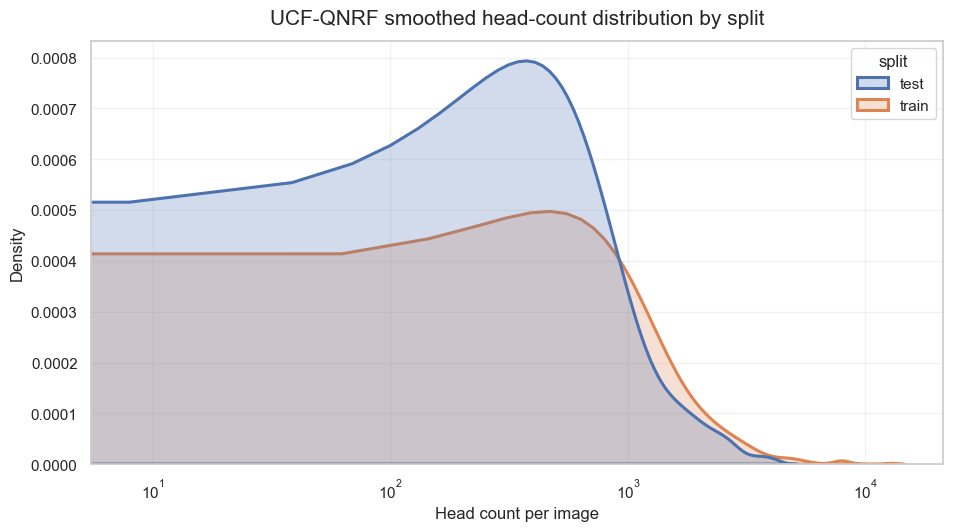

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_count_kde_by_split.png


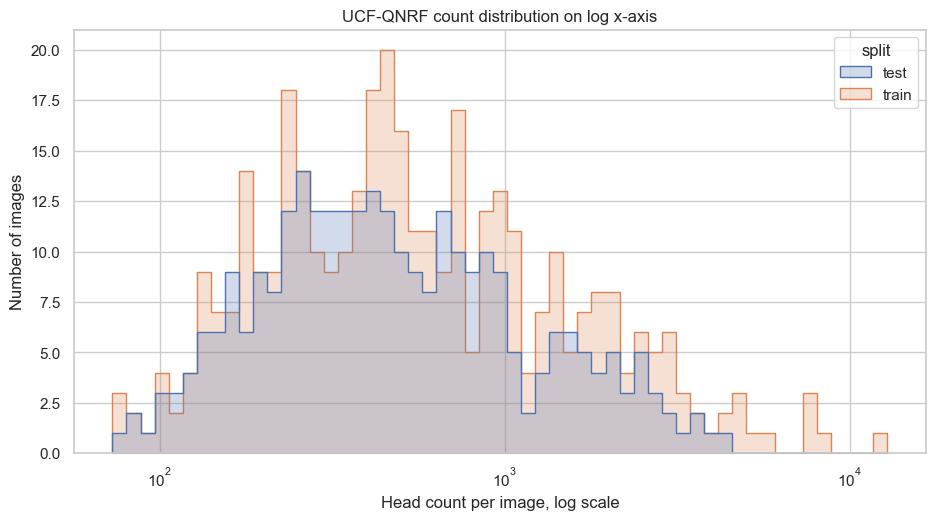

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_count_hist_logx.png


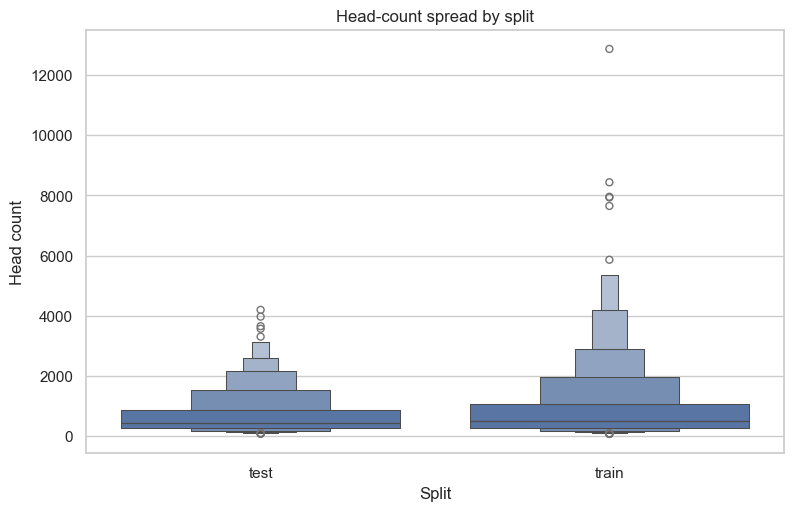

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_count_boxen_by_split.png


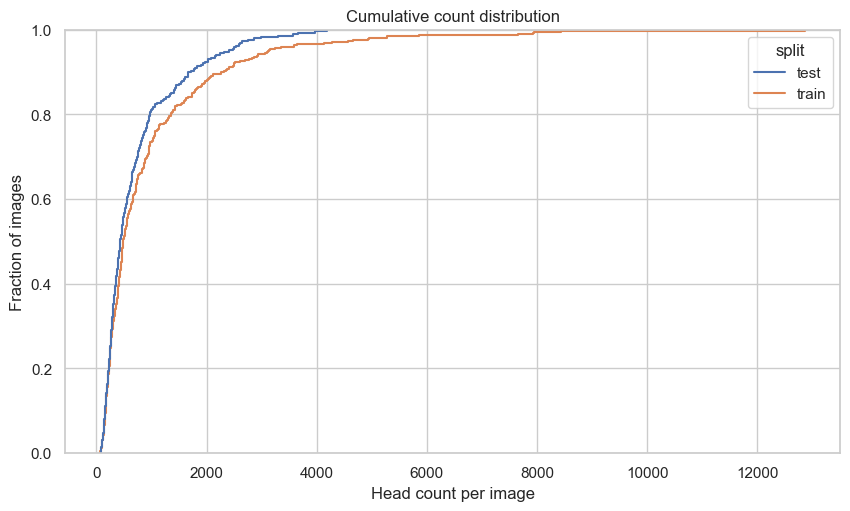

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_count_ecdf_by_split.png


In [9]:
labeled_df = df[df["has_label"] & df["count"].notna()].copy()
if labeled_df.empty:
    raise RuntimeError("No labels were loaded. Check .mat paths and the parser.")

fig, ax = plt.subplots(figsize=(11, 5.5))

sns.kdeplot(
    data=labeled_df,
    x="count",
    hue="split",
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2.2,
    bw_adjust=1.4,
    ax=ax
)

ax.set_title("UCF-QNRF smoothed head-count distribution by split", fontsize=15, pad=12)
ax.set_xlabel("Head count per image")
ax.set_ylabel("Density")

ax.set_xscale("log")
ax.grid(alpha=0.25)

save_show(fig, "ucf_qnrf_count_kde_by_split.png")

fig, ax = plt.subplots(figsize=(11, 5.5))
positive = labeled_df[labeled_df["count"] > 0]
sns.histplot(data=positive, x="count", hue="split", bins=55, element="step", stat="count", common_norm=False, log_scale=(True, False), ax=ax)
ax.set_title("UCF-QNRF count distribution on log x-axis")
ax.set_xlabel("Head count per image, log scale")
ax.set_ylabel("Number of images")
save_show(fig, "ucf_qnrf_count_hist_logx.png")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxenplot(data=labeled_df, x="split", y="count", ax=ax)
ax.set_title("Head-count spread by split")
ax.set_xlabel("Split")
ax.set_ylabel("Head count")
save_show(fig, "ucf_qnrf_count_boxen_by_split.png")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.ecdfplot(data=labeled_df, x="count", hue="split", ax=ax)
ax.set_title("Cumulative count distribution")
ax.set_xlabel("Head count per image")
ax.set_ylabel("Fraction of images")
save_show(fig, "ucf_qnrf_count_ecdf_by_split.png")


## 9. Resolution, aspect ratio, and crowd density per megapixel

UCF-QNRF images are large and varied. These plots help decide whether to tile, downsample, or use patch-based training.


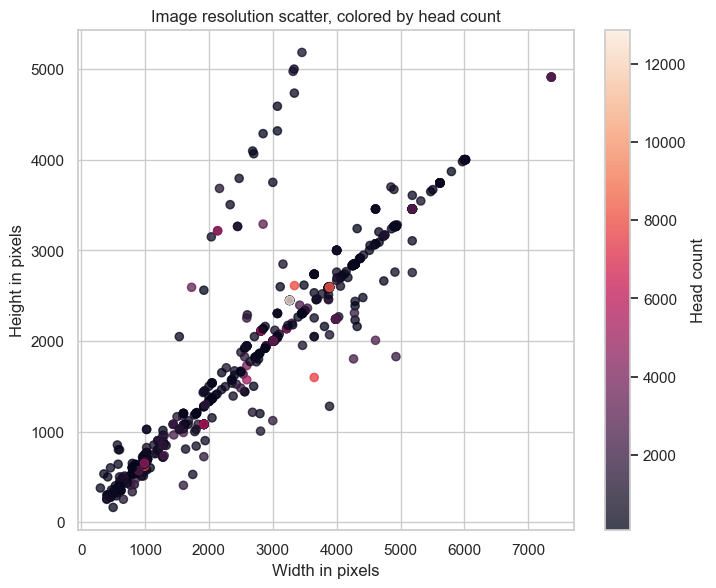

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_resolution_scatter_count.png


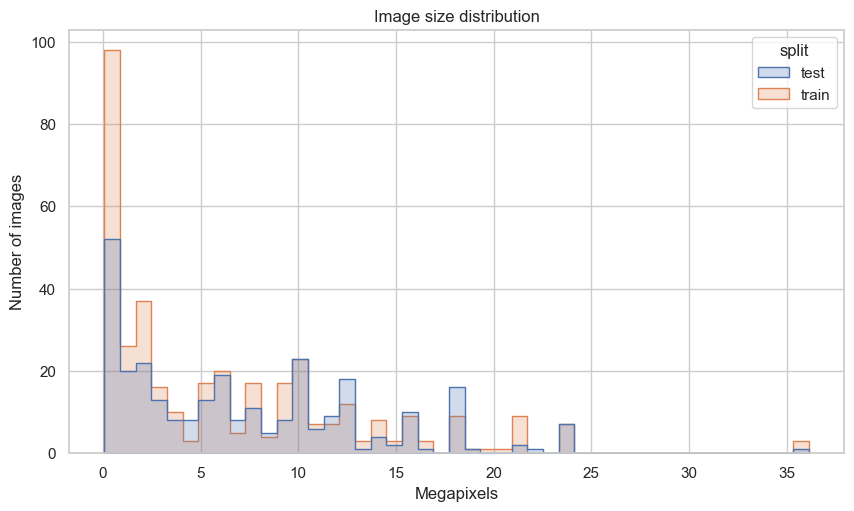

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_megapixels_hist.png


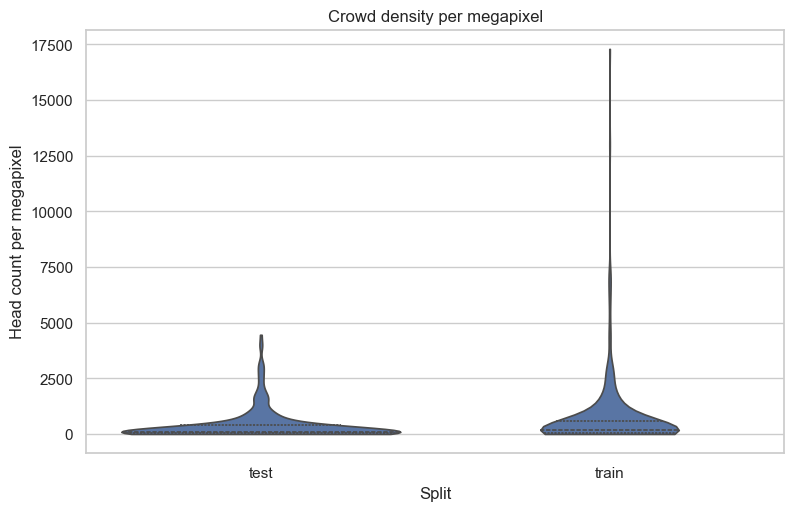

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_count_per_mp_violin.png


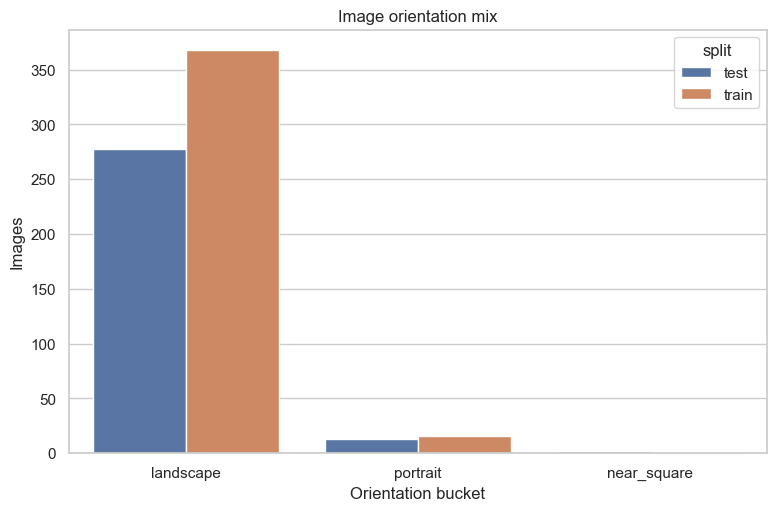

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_orientation_mix.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6.5))
scatter = ax.scatter(labeled_df["width"], labeled_df["height"], c=labeled_df["count"], s=35, alpha=0.75)
ax.set_title("Image resolution scatter, colored by head count")
ax.set_xlabel("Width in pixels")
ax.set_ylabel("Height in pixels")
fig.colorbar(scatter, ax=ax, label="Head count")
save_show(fig, "ucf_qnrf_resolution_scatter_count.png")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(data=labeled_df, x="megapixels", hue="split", bins=45, element="step", common_norm=False, ax=ax)
ax.set_title("Image size distribution")
ax.set_xlabel("Megapixels")
ax.set_ylabel("Number of images")
save_show(fig, "ucf_qnrf_megapixels_hist.png")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=labeled_df, x="split", y="count_per_megapixel", cut=0, inner="quartile", ax=ax)
ax.set_title("Crowd density per megapixel")
ax.set_xlabel("Split")
ax.set_ylabel("Head count per megapixel")
save_show(fig, "ucf_qnrf_count_per_mp_violin.png")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.countplot(data=df, x="orientation", hue="split", ax=ax)
ax.set_title("Image orientation mix")
ax.set_xlabel("Orientation bucket")
ax.set_ylabel("Images")
save_show(fig, "ucf_qnrf_orientation_mix.png")


## 10. Extremes and inspection tables


In [11]:
inspect_cols = ["split", "image_id", "width", "height", "megapixels", "count", "count_per_megapixel", "image_path", "label_path"]

print("Highest-count images")
display(labeled_df.sort_values("count", ascending=False)[inspect_cols].head(15))

print("Lowest-count images")
display(labeled_df.sort_values("count", ascending=True)[inspect_cols].head(15))

print("Most crowded per megapixel")
display(labeled_df.sort_values("count_per_megapixel", ascending=False)[inspect_cols].head(15))


Highest-count images


,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
670,train,img_1194,3264,2448,7.990272,12865.0,1610.082861,..\data\UCF-QNRF\Train\img_1194.jpg,..\data\UCF-QNRF\Train\img_1194_ann.mat
672,train,img_1196,3888,2592,10.077696,8434.0,836.897640,..\data\UCF-QNRF\Train\img_1196.jpg,..\data\UCF-QNRF\Train\img_1196_ann.mat
534,train,img_1044,991,618,0.612438,7953.0,12985.804277,..\data\UCF-QNRF\Train\img_1044.jpg,..\data\UCF-QNRF\Train\img_1044_ann.mat
532,train,img_1042,3339,2611,8.718129,7930.0,909.598837,..\data\UCF-QNRF\Train\img_1042.jpg,..\data\UCF-QNRF\Train\img_1042_ann.mat
669,train,img_1193,3648,1597,5.825856,7647.0,1312.596810,..\data\UCF-QNRF\Train\img_1193.jpg,..\data\UCF-QNRF\Train\img_1193_ann.mat
674,train,img_1198,1920,1080,2.073600,5860.0,2826.003086,..\data\UCF-QNRF\Train\img_1198.jpg,..\data\UCF-QNRF\Train\img_1198_ann.mat
350,train,img_0838,2816,2112,5.947392,5273.0,886.607104,..\data\UCF-QNRF\Train\img_0838.jpg,..\data\UCF-QNRF\Train\img_0838_ann.mat
673,train,img_1197,2136,3216,6.869376,4953.0,721.026189,..\data\UCF-QNRF\Train\img_1197.jpg,..\data\UCF-QNRF\Train\img_1197_ann.mat
529,train,img_1039,2592,1572,4.074624,4923.0,1208.209641,..\data\UCF-QNRF\Train\img_1039.jpg,..\data\UCF-QNRF\Train\img_1039_ann.mat
677,train,img_1201,990,650,0.643500,4663.0,7246.309246,..\data\UCF-QNRF\Train\img_1201.jpg,..\data\UCF-QNRF\Train\img_1201_ann.mat


Lowest-count images


,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
468,train,img_0970,4288,2848,12.212224,73.0,5.977617,..\data\UCF-QNRF\Train\img_0970.jpg,..\data\UCF-QNRF\Train\img_0970_ann.mat
517,train,img_1024,6016,4000,24.064000,73.0,3.033577,..\data\UCF-QNRF\Train\img_1024.jpg,..\data\UCF-QNRF\Train\img_1024_ann.mat
5,test,img_0007,2048,1536,3.145728,77.0,24.477641,..\data\UCF-QNRF\Test\img_0007.jpg,..\data\UCF-QNRF\Test\img_0007_ann.mat
456,train,img_0958,1800,1200,2.160000,80.0,37.037037,..\data\UCF-QNRF\Train\img_0958.jpg,..\data\UCF-QNRF\Train\img_0958_ann.mat
471,train,img_0973,4288,2232,9.570816,81.0,8.463228,..\data\UCF-QNRF\Train\img_0973.jpg,..\data\UCF-QNRF\Train\img_0973_ann.mat
217,test,img_0249,6016,4000,24.064000,83.0,3.449136,..\data\UCF-QNRF\Test\img_0249.jpg,..\data\UCF-QNRF\Test\img_0249_ann.mat
470,train,img_0972,4288,2387,10.235456,86.0,8.402166,..\data\UCF-QNRF\Train\img_0972.jpg,..\data\UCF-QNRF\Train\img_0972_ann.mat
34,test,img_0039,1280,853,1.091840,88.0,80.597890,..\data\UCF-QNRF\Test\img_0039.jpg,..\data\UCF-QNRF\Test\img_0039_ann.mat
6,test,img_0008,4240,2832,12.007680,92.0,7.661763,..\data\UCF-QNRF\Test\img_0008.jpg,..\data\UCF-QNRF\Test\img_0008_ann.mat
501,train,img_1007,4320,3240,13.996800,93.0,6.644376,..\data\UCF-QNRF\Train\img_1007.jpg,..\data\UCF-QNRF\Train\img_1007_ann.mat


Most crowded per megapixel


,split,image_id,width,height,megapixels,count,count_per_megapixel,image_path,label_path
631,train,img_1152,400,252,0.100800,1743.0,17291.666667,..\data\UCF-QNRF\Train\img_1152.jpg,..\data\UCF-QNRF\Train\img_1152_ann.mat
534,train,img_1044,991,618,0.612438,7953.0,12985.804277,..\data\UCF-QNRF\Train\img_1044.jpg,..\data\UCF-QNRF\Train\img_1044_ann.mat
677,train,img_1201,990,650,0.643500,4663.0,7246.309246,..\data\UCF-QNRF\Train\img_1201.jpg,..\data\UCF-QNRF\Train\img_1201_ann.mat
624,train,img_1144,980,653,0.639940,4561.0,7127.230678,..\data\UCF-QNRF\Train\img_1144.jpg,..\data\UCF-QNRF\Train\img_1144_ann.mat
602,train,img_1122,660,441,0.291060,2007.0,6895.485467,..\data\UCF-QNRF\Train\img_1122.jpg,..\data\UCF-QNRF\Train\img_1122_ann.mat
594,train,img_1110,773,408,0.315384,2125.0,6737.818025,..\data\UCF-QNRF\Train\img_1110.jpg,..\data\UCF-QNRF\Train\img_1110_ann.mat
655,train,img_1179,660,253,0.166980,1032.0,6180.380884,..\data\UCF-QNRF\Train\img_1179.jpg,..\data\UCF-QNRF\Train\img_1179_ann.mat
551,train,img_1066,854,480,0.409920,2499.0,6096.311475,..\data\UCF-QNRF\Train\img_1066.jpg,..\data\UCF-QNRF\Train\img_1066_ann.mat
646,train,img_1170,900,569,0.512100,2772.0,5413.005272,..\data\UCF-QNRF\Train\img_1170.jpg,..\data\UCF-QNRF\Train\img_1170_ann.mat
636,train,img_1157,400,258,0.103200,491.0,4757.751938,..\data\UCF-QNRF\Train\img_1157.jpg,..\data\UCF-QNRF\Train\img_1157_ann.mat


## 11. Visual audit: random labeled examples

For dense images, the scatter layer is capped to keep the notebook responsive. The title tells how many points are displayed.


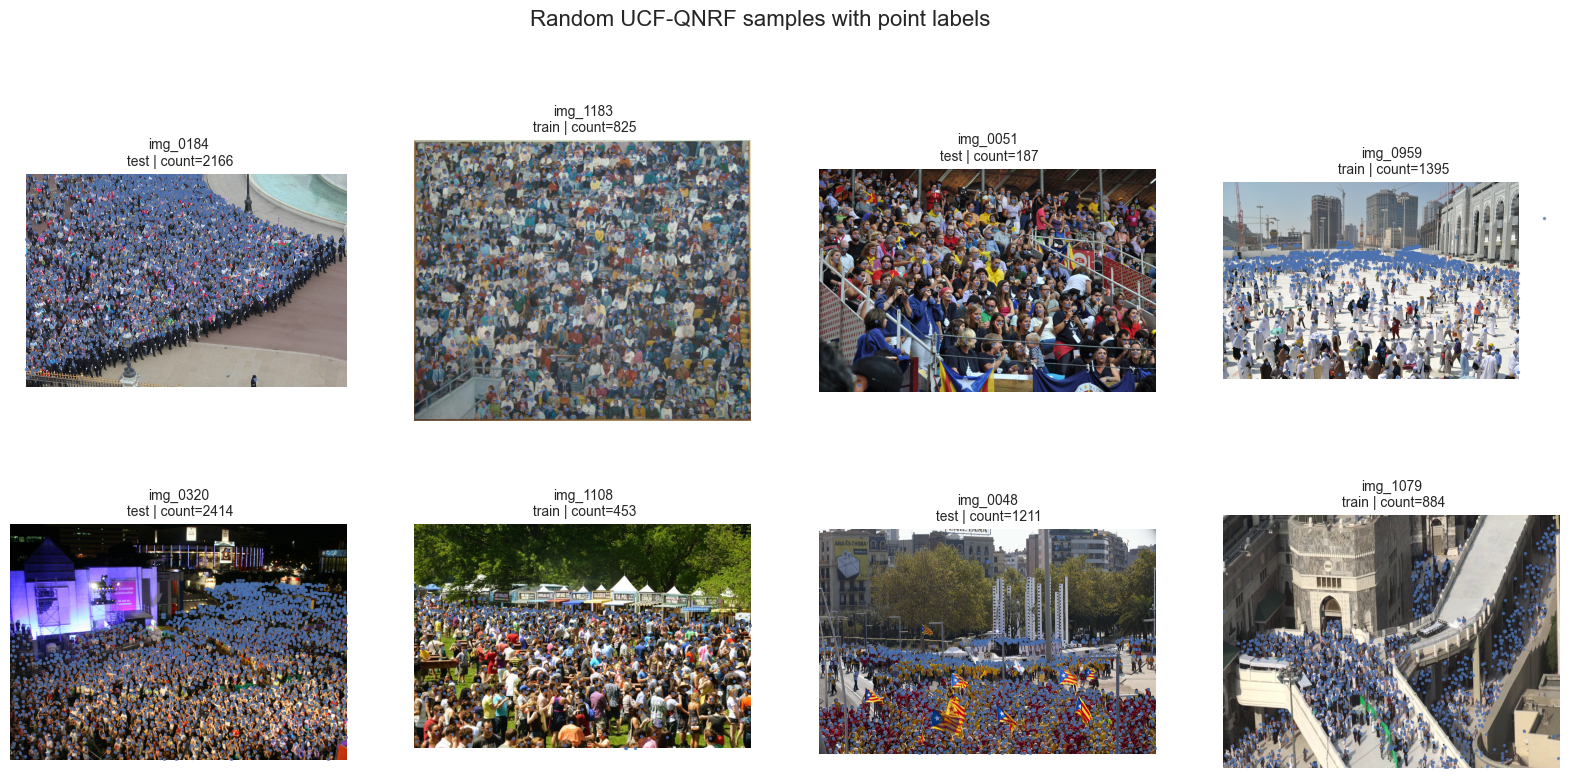

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_random_annotated_samples.png


In [12]:
sample = stratified_sample(labeled_df, ["split"], n_each=4, seed=SEED)
plot_annotated_samples(sample, "Random UCF-QNRF samples with point labels", "ucf_qnrf_random_annotated_samples.png", max_points=3000, ncols=4)


## 12. Visual audit: lowest and highest counts


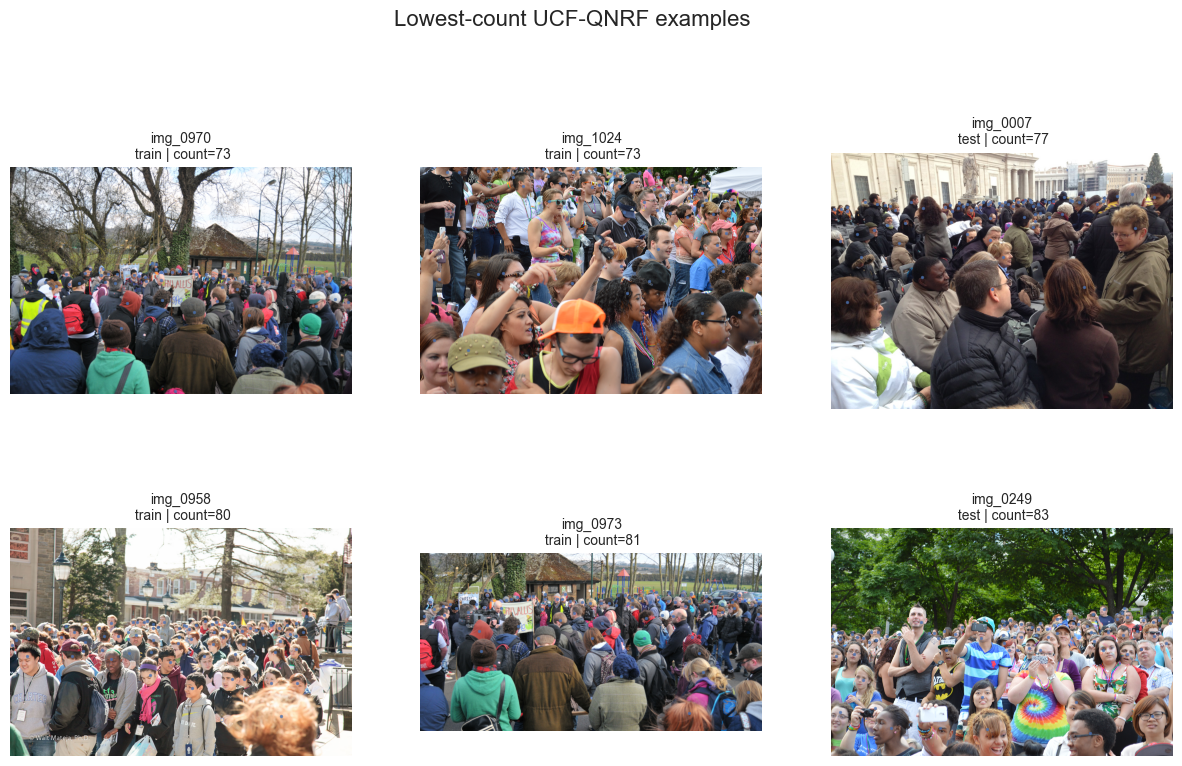

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_lowest_count_examples.png


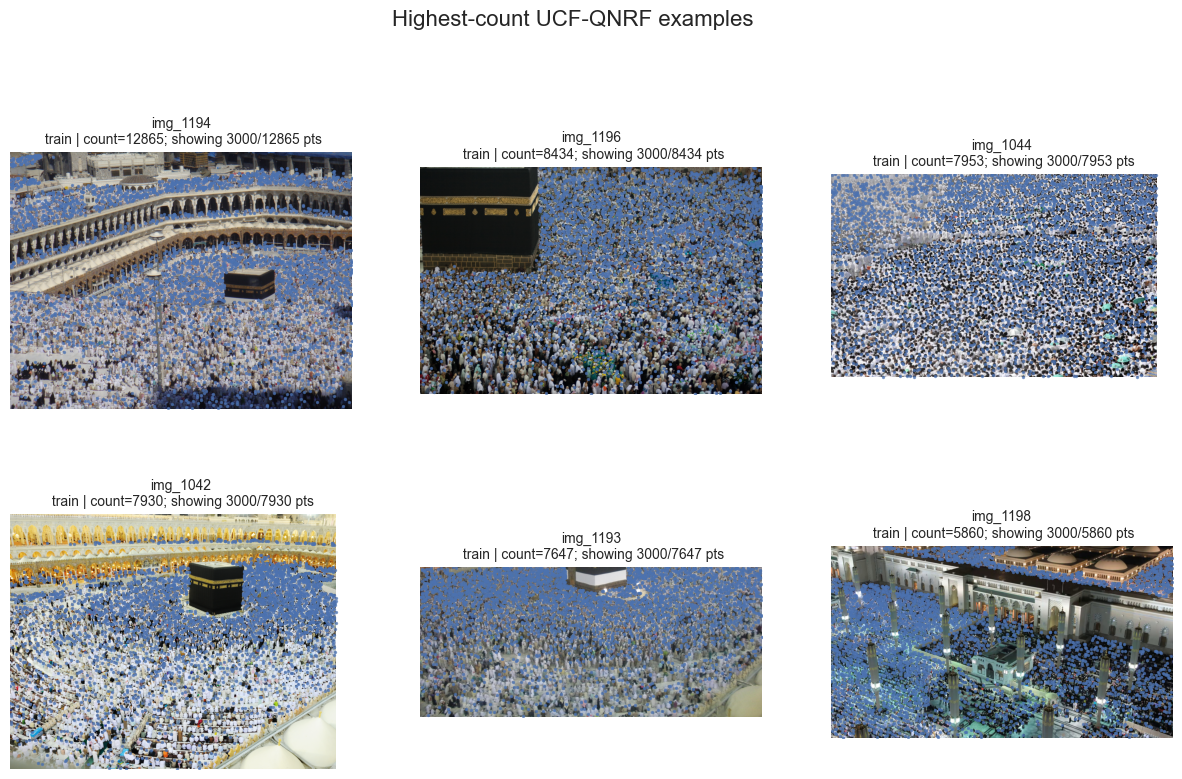

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_highest_count_examples.png


In [13]:
lowest = labeled_df.sort_values("count", ascending=True).head(6)
highest = labeled_df.sort_values("count", ascending=False).head(6)
plot_annotated_samples(lowest, "Lowest-count UCF-QNRF examples", "ucf_qnrf_lowest_count_examples.png", max_points=3000, ncols=3)
plot_annotated_samples(highest, "Highest-count UCF-QNRF examples", "ucf_qnrf_highest_count_examples.png", max_points=3000, ncols=3)


## 13. Normalized spatial annotation heatmaps

Each annotation is mapped to normalized image coordinates `(x / width, y / height)`. This highlights camera/framing biases independently of image size.


Loading points:   0%|          | 0/289 [00:00<?, ?it/s]

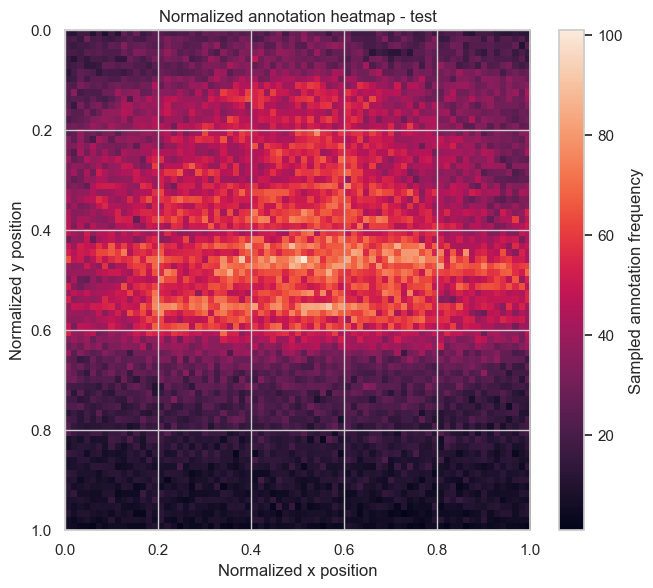

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_test_normalized_spatial_heatmap.png


Loading points:   0%|          | 0/376 [00:00<?, ?it/s]

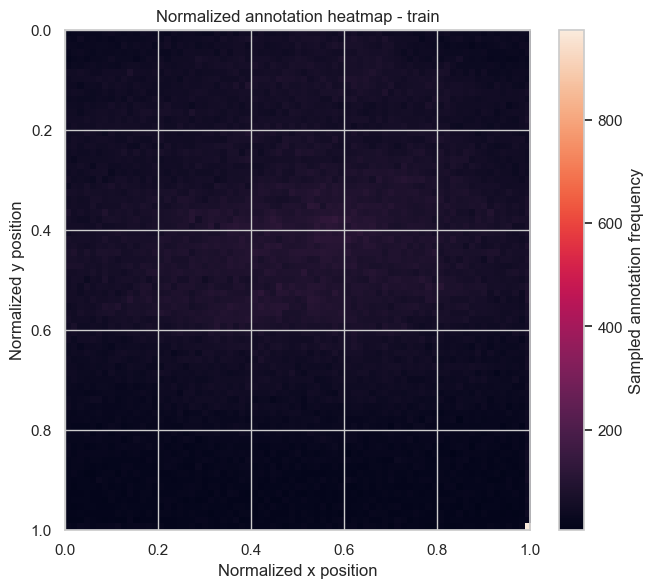

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_train_normalized_spatial_heatmap.png


In [14]:
for split in sorted(labeled_df["split"].dropna().unique()):
    split_df = labeled_df[labeled_df["split"] == split]
    plot_normalized_spatial_heatmap(
        split_df,
        title=f"Normalized annotation heatmap - {split}",
        filename=f"ucf_qnrf_{split.lower()}_normalized_spatial_heatmap.png",
        bins=75,
        max_points_per_image=2200,
    )


## 14. Density-map preview

This creates a visualization-only Gaussian density map from one high-count image. For training, choose density-map parameters carefully and preserve the density integral so it sums to the count.


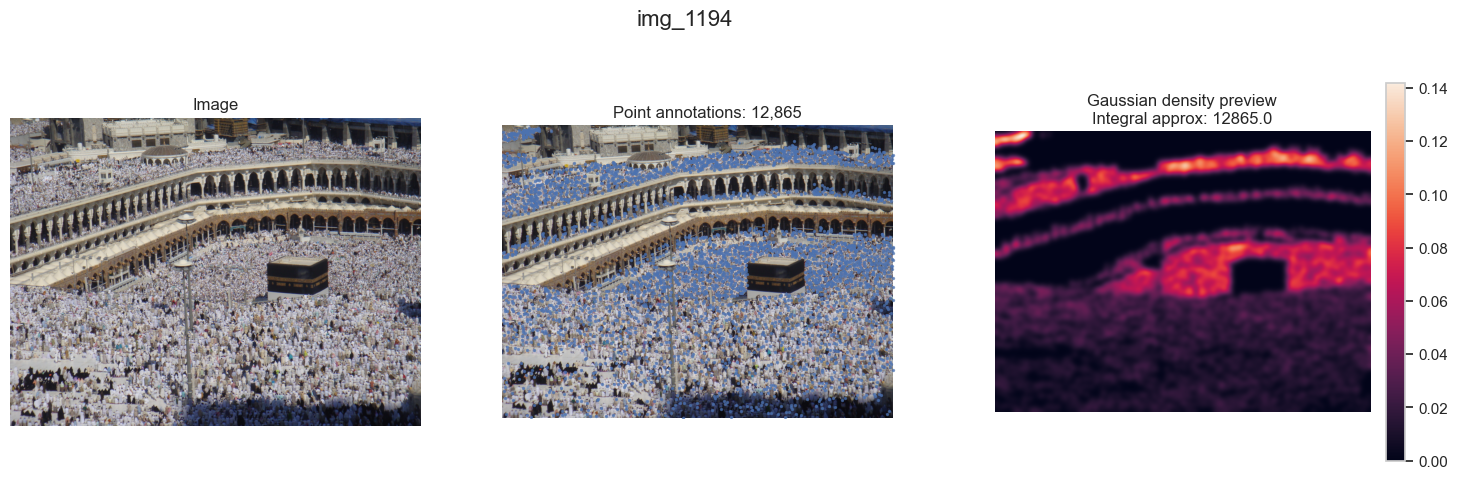

Saved: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_density_preview_high_count.png


In [15]:
row = labeled_df.sort_values("count", ascending=False).iloc[0]
make_density_preview(row, "ucf_qnrf_density_preview_high_count.png", max_side=900, sigma=7)


## 15. Export metadata

The exported CSV is useful for training scripts and for reproducible reporting.


In [16]:
metadata_path = OUTPUT_DIR / "ucf_qnrf_eda_metadata.csv"
df.to_csv(metadata_path, index=False)
print("Saved metadata:", metadata_path)

summary_path = OUTPUT_DIR / "ucf_qnrf_eda_summary.csv"
summary.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)


Saved metadata: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_eda_metadata.csv
Saved summary: crowd_counting_eda_outputs\UCF-QNRF\ucf_qnrf_eda_summary.csv
